# TECH CHALLENGE - FASE 1
**Case E-commerce Olist**

## Satisfação do Cliente

# 1. Objetivo

Este desafio tem como objetivo criar um relatório executivo voltado a
investidores e acionistas do setor de e-commerce, baseado no Brazilian E-Commerce Public Dataset by Olist.

Esta frente do trabalho analisa a **satisfação do cliente**, respondendo a três perguntas:

1. Como se distribuem as avaliações e quais os temas recorrentes nos comentários?
2. Quais são os drivers de satisfação (tempo de entrega, preço e categoria)?
3. Onde estão os riscos de churn?

A análise complementa diretamente a frente regional, que identificou concentração de oferta no Sudeste
e taxas de atraso elevadas no Norte e Nordeste, e atende ao item de Trabalhos Futuros daquele relatório:
*incluir a tabela de avaliações (order_reviews) para investigar a relação entre atraso na entrega e
satisfação do cliente por estado*.

# 2. Carregamento dos Dados

In [1]:
# Importação das Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

In [2]:
# Caminho dos dados
# No Google Colab, carregar os .csv em uma pasta "dataset"
CAMINHO = '../dataset/'   # em Colab, usar '/content/dataset/'

df_orders     = pd.read_csv(CAMINHO + 'orders.csv')
df_items      = pd.read_csv(CAMINHO + 'order_items.csv')
df_reviews    = pd.read_csv(CAMINHO + 'order_reviews.csv')
df_customers  = pd.read_csv(CAMINHO + 'customers.csv')
df_products   = pd.read_csv(CAMINHO + 'products.csv')
df_traducao   = pd.read_csv(CAMINHO + 'product_category_name_translation.csv')

In [3]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Foram utilizadas cinco tabelas do dataset original. A tabela `order_reviews` é a base central desta
análise e contém a nota atribuída pelo cliente (`review_score`), o título e o texto do comentário, além
das datas de criação e resposta da avaliação.

As demais tabelas foram incorporadas para permitir o cruzamento da nota com as variáveis explicativas:
`orders` fornece os marcos temporais do pedido, `order_items` os valores de preço e frete, `customers`
a localização do comprador e `products` mais `product_category_name_translation` a categoria do produto.

# 3. Inspeção e Preparação dos Dados

In [4]:
# Verificação dos dtypes de cada coluna em df_reviews
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [5]:
# Verificar integridade da chave: existe mais de um review por pedido?
reviews_por_pedido = df_reviews['order_id'].value_counts()

print('Total de linhas:', len(df_reviews))
print('Pedidos distintos:', df_reviews['order_id'].nunique())
print('Pedidos com mais de um review:', (reviews_por_pedido > 1).sum())

pedidos_dup = reviews_por_pedido[reviews_por_pedido > 1].index
notas_divergentes = (
    df_reviews[df_reviews['order_id'].isin(pedidos_dup)]
    .groupby('order_id')['review_score']
    .nunique()
    .gt(1)
    .sum()
)
print('Destes, com notas divergentes entre si:', notas_divergentes)

Total de linhas: 99224
Pedidos distintos: 98673
Pedidos com mais de um review: 547
Destes, com notas divergentes entre si: 202


In [6]:
# Deduplicação: manter apenas a avaliação mais recente de cada pedido
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])

df_reviews_dedup = (
    df_reviews
    .sort_values('review_creation_date')
    .drop_duplicates('order_id', keep='last')
)

print('Base deduplicada:', len(df_reviews_dedup), 'avaliações')

Base deduplicada: 98673 avaliações


A primeira verificação identificou uma inconsistência de granularidade: a tabela `order_reviews`
possui mais linhas do que pedidos distintos, ou seja, alguns pedidos receberam mais de uma avaliação.
Parte desses casos apresenta notas divergentes entre si para o mesmo pedido.

Como todas as métricas desta análise são calculadas por pedido, a duplicidade produziria dupla contagem
e enviesaria as médias. Optou-se pela deduplicação mantendo a avaliação mais recente de cada pedido,
critério que preserva a manifestação final do cliente. Essa decisão é registrada aqui por afetar
levemente os valores absolutos em relação a análises que utilizem a base bruta.

In [7]:
# Passar as colunas de datas para datetime
colunas_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for coluna in colunas_data:
    df_orders[coluna] = pd.to_datetime(df_orders[coluna])

In [8]:
# Agregar itens ao nível do pedido (preço, frete, nº de itens e nº de vendedores)
itens_agregados = df_items.groupby('order_id').agg(
    qtd_itens=('order_item_id', 'max'),
    qtd_vendedores=('seller_id', 'nunique'),
    preco=('price', 'sum'),
    frete=('freight_value', 'sum'),
    produto_id=('product_id', 'first')
).reset_index()

itens_agregados.head()

,order_id,qtd_itens,qtd_vendedores,preco,frete,produto_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29,4244733e06e7ecb4970a6e2683c13e61
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93,e5f2d52b802189ee658865ca93d83a8f
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87,c777355d18b72b67abbeef9df44fd0fd
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79,7634da152a4610f1595efa32f14722fc
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14,ac6c3623068f30de03045865e4e10089


In [9]:
# Junção das tabelas
df = (
    df_orders
    .merge(itens_agregados, on='order_id')
    .merge(df_reviews_dedup[['order_id', 'review_score',
                             'review_comment_message', 'review_creation_date']],
           on='order_id')
    .merge(df_customers, on='customer_id')
    .merge(df_products[['product_id', 'product_category_name']],
           left_on='produto_id', right_on='product_id', how='left')
    .merge(df_traducao, on='product_category_name', how='left')
)

print('Registros após junção:', len(df))

Registros após junção: 97917


In [10]:
# Filtrar apenas pedidos entregues
# A satisfação só pode ser avaliada sobre pedidos que completaram o ciclo
df = df[df['order_status'] == 'delivered'].copy()

print('Pedidos entregues e avaliados:', len(df))

Pedidos entregues e avaliados: 95832


In [11]:
# Criar as colunas derivadas de prazo
# tempo_entrega: dias entre a compra e a entrega ao cliente
df['tempo_entrega'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# tempo_estimado: prazo prometido ao cliente no momento da compra
df['tempo_estimado'] = (
    df['order_estimated_delivery_date'] - df['order_purchase_timestamp']
).dt.days

# dias_atraso: positivo quando a entrega ocorreu após a data estimada
df['dias_atraso'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# indicador binário de atraso
df['atrasado'] = np.where(df['dias_atraso'] > 0, 1, 0)

In [12]:
# Tratar categoria nula e criar coluna de ano
df['categoria'] = df['product_category_name_english'].fillna('outros')
df['ano'] = df['order_purchase_timestamp'].dt.year

# Remover registros sem nota ou sem data de entrega
df = df.dropna(subset=['review_score', 'dias_atraso'])

print('Base analítica final:', len(df), 'pedidos')
print('Período:', df['order_purchase_timestamp'].min().date(),
      'a', df['order_purchase_timestamp'].max().date())

Base analítica final: 95824 pedidos
Período: 2016-09-15 a 2018-08-29


Na etapa de preparação, as colunas de data foram convertidas para o tipo `datetime`, uma vez que
estavam originalmente como `object`, o que impediria o cálculo de diferenças temporais.

A tabela `order_items` possui granularidade de item, enquanto a análise de satisfação opera no nível do
pedido, já que a avaliação é única por pedido. Por isso os itens foram previamente agregados por
`order_id`, somando preço e frete e contabilizando a quantidade de itens e de vendedores distintos.
Essas duas últimas variáveis foram mantidas por serem candidatas a drivers de satisfação.

A partir das colunas de data foram calculadas as métricas `tempo_entrega`, `tempo_estimado` e
`dias_atraso`, além do indicador binário `atrasado`. Diferentemente da frente regional, que utilizou
`order_approved_at` como marco inicial, aqui adotou-se `order_purchase_timestamp`, pois a percepção do
cliente sobre o prazo começa no momento da compra, não no da aprovação do pagamento.

Por fim, a base foi restrita a pedidos com status `delivered`, condição necessária para que exista uma
experiência de entrega a ser avaliada.

# 4. Análise Exploratória (EDA)

A análise exploratória foi organizada em torno dos três eixos definidos no objetivo.

Indicadores a serem analisados na EDA:

Distribuição de review_score e cálculo do NPS adaptado;

Momento de criação da avaliação em relação à entrega;

Temas recorrentes nos comentários (text mining);

Review por atraso;

Review por tempo de entrega;

Review por categoria de produto;

Review por região e por estado;

Taxa de recompra e riscos de churn.

## 4.1 Distribuição de review_score

In [13]:
# Distribuição das notas
distribuicao = df['review_score'].value_counts().sort_index().reset_index()
distribuicao.columns = ['nota', 'pedidos']
distribuicao['percentual'] = distribuicao['pedidos'] / distribuicao['pedidos'].sum() * 100
distribuicao['percentual_acumulado'] = distribuicao['percentual'].cumsum()

distribuicao.round(2)

,nota,pedidos,percentual,percentual_acumulado
0,1,9352,9.76,9.76
1,2,2920,3.05,12.81
2,3,7917,8.26,21.07
3,4,18893,19.72,40.79
4,5,56742,59.21,100.00


In [14]:
print(f"Nota média:    {df['review_score'].mean():.2f}")
print(f"Nota mediana:  {df['review_score'].median():.0f}")
print(f"Desvio padrão: {df['review_score'].std():.2f}")

Nota média:    4.16
Nota mediana:  5
Desvio padrão: 1.28


In [15]:
# NPS adaptado à escala de 5 pontos
# Promotores: nota 5 | Neutros: nota 4 | Detratores: notas 1 a 3
promotores  = (df['review_score'] == 5).mean() * 100
neutros     = (df['review_score'] == 4).mean() * 100
detratores  = (df['review_score'] <= 3).mean() * 100
nps = promotores - detratores

print(f'Promotores (nota 5):     {promotores:.1f}%')
print(f'Neutros (nota 4):        {neutros:.1f}%')
print(f'Detratores (notas 1-3):  {detratores:.1f}%')
print(f'\nNPS adaptado: {nps:.1f}')

Promotores (nota 5):     59.2%
Neutros (nota 4):        19.7%
Detratores (notas 1-3):  21.1%

NPS adaptado: 38.1


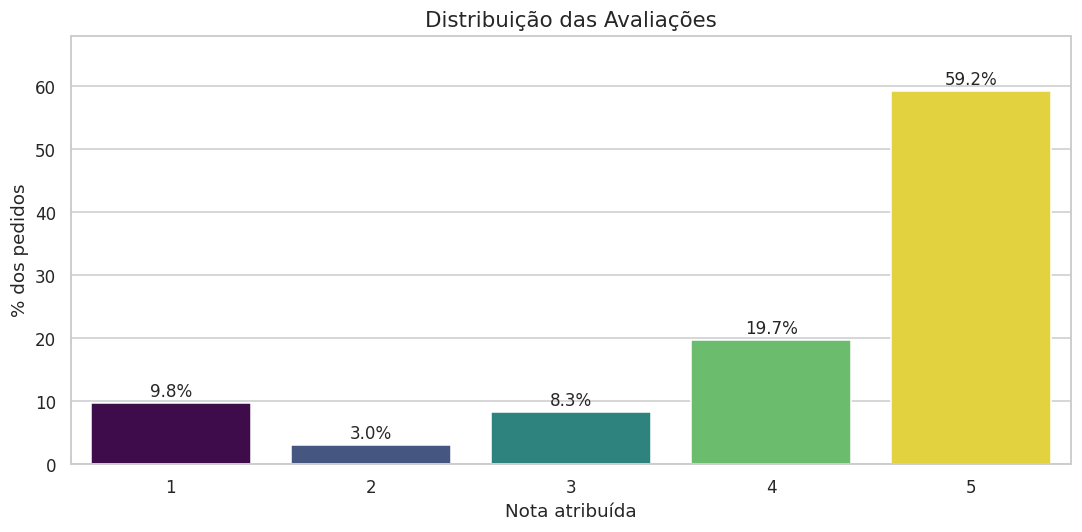

In [16]:
# Gráfico de barras da distribuição de notas
plt.figure(figsize=(10, 5))

gr = sns.barplot(
    data=distribuicao,
    x='nota',
    y='percentual',
    hue='nota',
    palette='viridis',
    legend=False
)

for i, linha in distribuicao.iterrows():
    gr.text(i, linha['percentual'] + 1, f"{linha['percentual']:.1f}%",
            ha='center', fontsize=11)

plt.xlabel('Nota atribuída')
plt.ylabel('% dos pedidos')
plt.title('Distribuição das Avaliações', fontsize=14)
plt.ylim(0, 68)

plt.tight_layout()
plt.show()

A distribuição das avaliações apresenta o formato conhecido como curva em J, característico de
plataformas de e-commerce: forte concentração na nota máxima, um vale nas notas intermediárias e um
novo acúmulo na nota mínima.

Esse formato indica polarização. O cliente tende a avaliar quando a experiência foi claramente positiva
ou claramente negativa, sendo a nota 2 a menos frequente de toda a escala. Para fins de leitura
executiva, a média isolada de aproximadamente 4,2 é pouco informativa, pois esconde um contingente
relevante de clientes na base da escala.

O NPS adaptado foi calculado tratando a nota 5 como promotora, a nota 4 como neutra e as notas de 1 a 3
como detratoras. Trata-se de uma adaptação da metodologia original, que opera em escala de 0 a 10, e é
utilizada aqui como indicador comparativo entre recortes, não como valor absoluto de mercado.

## 4.2 Momento de criação da avaliação

In [17]:
# Diferença em dias entre a criação do review e a entrega do pedido
df['dias_review_pos_entrega'] = (
    df['review_creation_date'] - df['order_delivered_customer_date']
).dt.days

pct_no_dia = (df['dias_review_pos_entrega'] == 0).mean() * 100

print(f'Avaliações criadas no dia exato da entrega: {pct_no_dia:.1f}%')
print(f'Mediana de dias entre entrega e avaliação: '
      f"{df['dias_review_pos_entrega'].median():.0f}")

Avaliações criadas no dia exato da entrega: 89.0%
Mediana de dias entre entrega e avaliação: 0


Esta verificação é uma ressalva metodológica relevante para a interpretação de toda a análise.

A quase totalidade das avaliações é registrada no mesmo dia em que o pedido é entregue, o que indica que
a pesquisa de satisfação é disparada automaticamente pelo evento logístico de entrega, e não pelo uso do
produto.

A consequência é direta: `review_score` mede a **experiência de recebimento**, não a qualidade
intrínseca do produto. Atributos como durabilidade, adequação ao uso e desempenho estão
estruturalmente sub-representados nesta métrica. Toda conclusão a seguir deve ser lida sob essa
limitação.

## 4.3 Temas recorrentes nos comentários (text mining)

In [18]:
# Normalização do texto: minúsculas, remoção de acentos e de pontuação
def normalizar_texto(texto):
    if pd.isna(texto):
        return ''
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))
    return re.sub(r'[^a-z\s]', ' ', texto)

df['comentario'] = df['review_comment_message'].apply(normalizar_texto)

df_comentarios = df[df['comentario'].str.strip() != ''].copy()

print(f'Pedidos com comentário escrito: {len(df_comentarios):,} '
      f'({len(df_comentarios) / len(df) * 100:.1f}% do total)')

Pedidos com comentário escrito: 38,717 (40.4% do total)


In [19]:
# Propensão a comentar por nota
propensao = (
    df.assign(tem_comentario=df['comentario'].str.strip() != '')
      .groupby('review_score')['tem_comentario']
      .mean()
      .mul(100)
      .reset_index(name='pct_com_comentario')
)

propensao.round(1)

,review_score,pct_com_comentario
0,1,77.5
1,2,67.7
2,3,43.2
3,4,30.9
4,5,35.7


In [20]:
# Dicionário de temas por expressões regulares
temas = {
    'Sem resposta / suporte': r'(nao|nenhuma|sem) (obtive |tive |ha )?(resposta|retorno)|nao respond|aguardo retorno|ninguem responde|sem suporte',
    'Pedido de reembolso':    r'dinheiro de volta|devolucao|reembols|estorno|quero meu dinheiro',
    'Não recebeu':            r'nao recebi|nao chegou|nada recebi|nao foi entregue|nunca chegou|nao entregaram',
    'Produto errado':         r'produto errado|veio errado|diferente do (anunciado|pedido|site)|outro produto|cor errada|tamanho errado',
    'Entrega parcial':        r'recebi (apenas|somente|so )|veio (apenas|somente|so )|faltou|falta (um|uma|produto|item)|metade',
    'Produto com defeito':    r'defeito|quebrad|danificad|estragado|rasgad|amassad|nao funciona|trincad',
    'Atraso':                 r'atras|demor|fora do prazo|prazo estourado|muito tempo',
    'Qualidade abaixo':       r'pessima qualidade|ma qualidade|qualidade ruim|baixa qualidade|material ruim|fragil',
    'Elogio ao produto':      r'otimo produto|excelente|otima qualidade|amei|perfeito|adorei|recomendo',
    'Elogio à entrega':       r'entregue antes|antes do prazo|chegou antes|super rapid|entrega rapida|rapidissim',
}

for tema, padrao in temas.items():
    df_comentarios[tema] = df_comentarios['comentario'].str.contains(padrao, regex=True)

/tmp/ipykernel_519/3900147497.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_comentarios[tema] = df_comentarios['comentario'].str.contains(padrao, regex=True)


In [21]:
# Consolidar volume e nota média por tema
resultado_temas = []

for tema in temas:
    subset = df_comentarios[df_comentarios[tema]]
    resultado_temas.append({
        'tema': tema,
        'volume': len(subset),
        'pct_dos_comentarios': len(subset) / len(df_comentarios) * 100,
        'nota_media': subset['review_score'].mean(),
        'pct_nota_1': (subset['review_score'] == 1).mean() * 100
    })

tabela_temas = pd.DataFrame(resultado_temas).sort_values('nota_media').reset_index(drop=True)
tabela_temas.round(2)

,tema,volume,pct_dos_comentarios,nota_media,pct_nota_1
0,Sem resposta / suporte,296,0.76,1.38,80.74
1,Não recebeu,2626,6.78,1.50,74.33
2,Pedido de reembolso,518,1.34,1.50,75.68
3,Produto errado,400,1.03,1.82,63.00
4,Entrega parcial,741,1.91,1.95,55.47
5,Produto com defeito,1060,2.74,2.21,47.55
6,Atraso,1337,3.45,2.64,35.08
7,Qualidade abaixo,1004,2.59,3.70,21.02
8,Elogio ao produto,8702,22.48,4.68,3.29
9,Elogio à entrega,5801,14.98,4.76,0.88


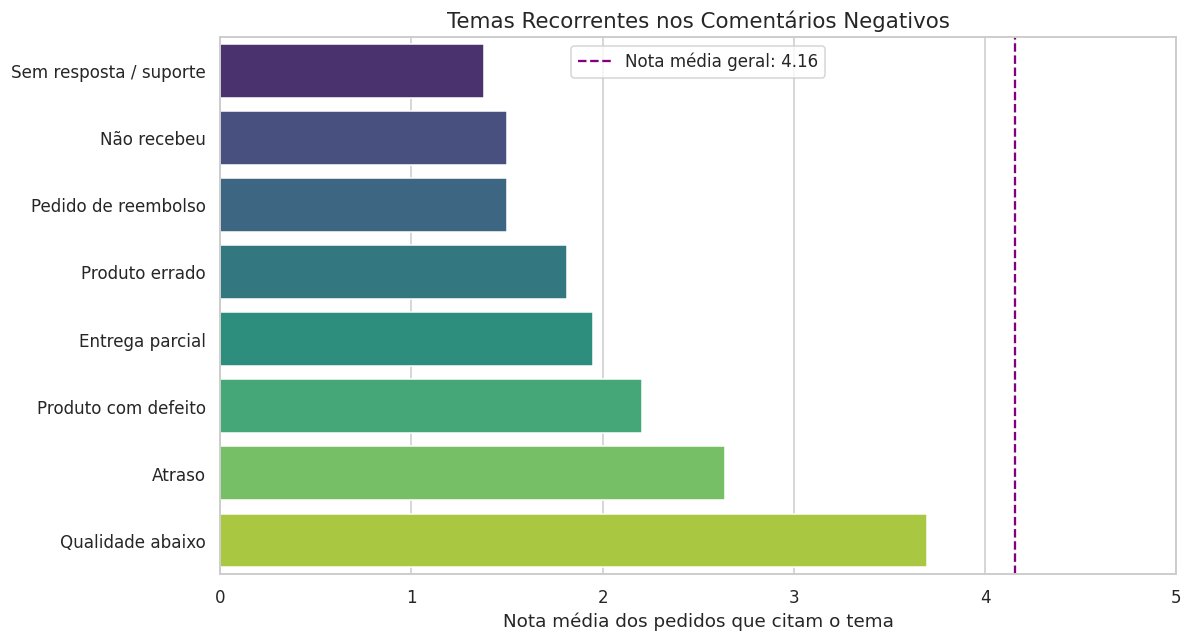

In [22]:
# Gráfico dos temas negativos ordenados por destrutividade
temas_negativos = tabela_temas[~tabela_temas['tema'].str.startswith('Elogio')]

plt.figure(figsize=(11, 6))

sns.barplot(
    data=temas_negativos,
    y='tema',
    x='nota_media',
    hue='tema',
    palette='viridis',
    legend=False
)

plt.axvline(df['review_score'].mean(), color='purple', linestyle='--', linewidth=1.5,
            label=f"Nota média geral: {df['review_score'].mean():.2f}")

plt.xlabel('Nota média dos pedidos que citam o tema')
plt.ylabel('')
plt.title('Temas Recorrentes nos Comentários Negativos', fontsize=14)
plt.xlim(0, 5)
plt.legend()

plt.tight_layout()
plt.show()

O text mining foi conduzido por classificação temática via expressões regulares, aplicada sobre os
comentários normalizados. Optou-se por essa abordagem em vez de modelagem de tópicos não supervisionada
porque o objetivo é quantificar categorias acionáveis de problema operacional, e não descobrir
agrupamentos latentes.

Um mesmo comentário pode ser classificado em mais de um tema, de modo que as proporções não somam 100%.

O achado central contraria a leitura intuitiva. O tema mais destrutivo não é o atraso na entrega, e sim
a **ausência de resposta ao cliente**: comentários que mencionam falta de retorno do suporte apresentam
a menor nota média de toda a taxonomia, abaixo inclusive dos casos em que o produto não foi recebido.
Em seguida aparecem os pedidos de reembolso e os relatos de não recebimento.

O atraso, por sua vez, figura entre os temas de menor severidade relativa dentro do conjunto de
reclamações. A leitura executiva é que a falha operacional é tolerável pelo cliente; o silêncio
posterior a ela não é.

A análise de propensão a comentar reforça um viés relevante: clientes insatisfeitos escrevem muito mais
do que clientes satisfeitos. Isso amplifica a exposição reputacional de cada falha, já que o conteúdo
público da plataforma é desproporcionalmente negativo em relação à experiência média real.

## 4.4 Review por atraso

In [23]:
# Faixas de atraso
faixas_atraso = pd.cut(
    df['dias_atraso'],
    bins=[-999, -1, 0, 1, 3, 7, 15, 999],
    labels=['Adiantado', 'No dia', '1 dia', '2-3 dias',
            '4-7 dias', '8-15 dias', '16+ dias']
)

review_por_atraso = df.groupby(faixas_atraso, observed=True).agg(
    pedidos=('review_score', 'size'),
    nota_media=('review_score', 'mean'),
    pct_nota_1=('review_score', lambda x: (x == 1).mean() * 100),
    pct_nota_5=('review_score', lambda x: (x == 5).mean() * 100)
).reset_index()

review_por_atraso['pct_da_base'] = (
    review_por_atraso['pedidos'] / review_por_atraso['pedidos'].sum() * 100
)

review_por_atraso.round(2)

,dias_atraso,pedidos,nota_media,pct_nota_1,pct_nota_5,pct_da_base
0,Adiantado,88163,4.29,6.59,62.43,92.01
1,No dia,1280,4.03,8.52,50.62,1.34
2,1 dia,820,3.73,13.05,40.61,0.86
3,2-3 dias,1032,2.94,34.69,27.23,1.08
4,4-7 dias,1748,2.10,58.58,14.13,1.82
5,8-15 dias,1601,1.67,70.21,6.68,1.67
6,16+ dias,1180,1.73,69.41,7.46,1.23


In [24]:
# Visão binária: com e sem atraso
resumo_atraso = df.groupby('atrasado').agg(
    pedidos=('review_score', 'size'),
    nota_media=('review_score', 'mean'),
    pct_nota_1=('review_score', lambda x: (x == 1).mean() * 100)
).reset_index()

resumo_atraso['atrasado'] = resumo_atraso['atrasado'].map({0: 'No prazo', 1: 'Com atraso'})
resumo_atraso.round(2)

,atrasado,pedidos,nota_media,pct_nota_1
0,No prazo,89443,4.29,6.62
1,Com atraso,6381,2.27,53.78


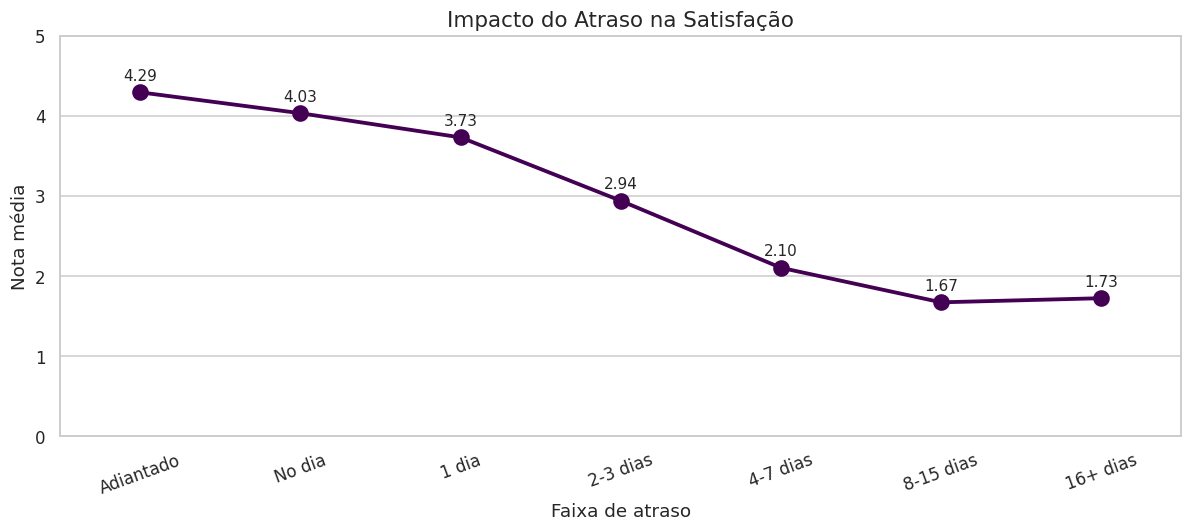

In [25]:
# Gráfico da curva de dano
plt.figure(figsize=(11, 5))

gr = sns.pointplot(
    data=review_por_atraso,
    x='dias_atraso',
    y='nota_media',
    color='#440154',
    markersize=9,
    linewidth=2.5
)

for i, linha in review_por_atraso.iterrows():
    gr.text(i, linha['nota_media'] + 0.15, f"{linha['nota_media']:.2f}",
            ha='center', fontsize=10)

plt.xlabel('Faixa de atraso')
plt.ylabel('Nota média')
plt.title('Impacto do Atraso na Satisfação', fontsize=14)
plt.ylim(0, 5)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

O atraso é o fator de maior impacto isolado sobre a satisfação em todo o conjunto de dados. Pedidos
entregues dentro do prazo apresentam nota média próxima de 4,3, enquanto pedidos atrasados caem para
aproximadamente 2,3, uma diferença de cerca de dois pontos em uma escala de cinco.

O comportamento não é linear. Um dia de atraso reduz a nota de forma moderada, mas a partir do segundo
dia a queda se acelera bruscamente, e entre o quarto e o sétimo dia a nota média já se encontra abaixo
do ponto médio da escala. A partir do oitavo dia o indicador satura em torno de 1,7, ou seja, atrasos
adicionais deixam de produzir dano marginal relevante porque o cliente já atribuiu a nota mínima.

Em termos de risco, mais da metade dos pedidos atrasados recebe nota 1, contra aproximadamente 7% dos
pedidos entregues no prazo. A existência de um ponto de ruptura entre o segundo e o quarto dia sugere
uma janela operacional de recuperação: ações de comunicação proativa ou compensação executadas nas
primeiras 72 horas de atraso atuam antes do colapso da percepção.

## 4.5 Review por tempo de entrega

In [26]:
# Faixas de tempo de entrega
faixas_tempo = pd.cut(
    df['tempo_entrega'],
    bins=[-1, 3, 7, 10, 15, 20, 30, 999],
    labels=['até 3d', '4-7d', '8-10d', '11-15d', '16-20d', '21-30d', '30d+']
)

review_por_tempo = df.groupby(faixas_tempo, observed=True).agg(
    pedidos=('review_score', 'size'),
    nota_media=('review_score', 'mean'),
    pct_nota_1=('review_score', lambda x: (x == 1).mean() * 100),
    taxa_atraso=('atrasado', 'mean')
).reset_index()

review_por_tempo['taxa_atraso'] *= 100
review_por_tempo.round(2)

,tempo_entrega,pedidos,nota_media,pct_nota_1,taxa_atraso
0,até 3d,8565,4.46,5.00,0.07
1,4-7d,24974,4.39,5.53,0.35
2,8-10d,18300,4.32,6.44,0.69
3,11-15d,21037,4.25,7.19,1.31
4,16-20d,10636,4.09,9.05,3.79
5,21-30d,8305,3.58,19.39,26.85
6,30d+,4007,2.17,56.83,81.21


In [27]:
# Isolar o efeito do tempo puro, removendo os pedidos atrasados
df_no_prazo = df[df['atrasado'] == 0].copy()

faixas_tempo_prazo = pd.cut(
    df_no_prazo['tempo_entrega'],
    bins=[-1, 3, 7, 10, 15, 20, 30, 999],
    labels=['até 3d', '4-7d', '8-10d', '11-15d', '16-20d', '21-30d', '30d+']
)

tempo_controlado = df_no_prazo.groupby(faixas_tempo_prazo, observed=True).agg(
    pedidos=('review_score', 'size'),
    nota_media=('review_score', 'mean'),
    pct_nota_1=('review_score', lambda x: (x == 1).mean() * 100)
).reset_index()

tempo_controlado.round(2)

,tempo_entrega,pedidos,nota_media,pct_nota_1
0,até 3d,8559,4.46,5.00
1,4-7d,24887,4.39,5.50
2,8-10d,18174,4.33,6.32
3,11-15d,20762,4.26,6.88
4,16-20d,10233,4.14,7.99
5,21-30d,6075,3.96,9.83
6,30d+,753,3.59,17.26


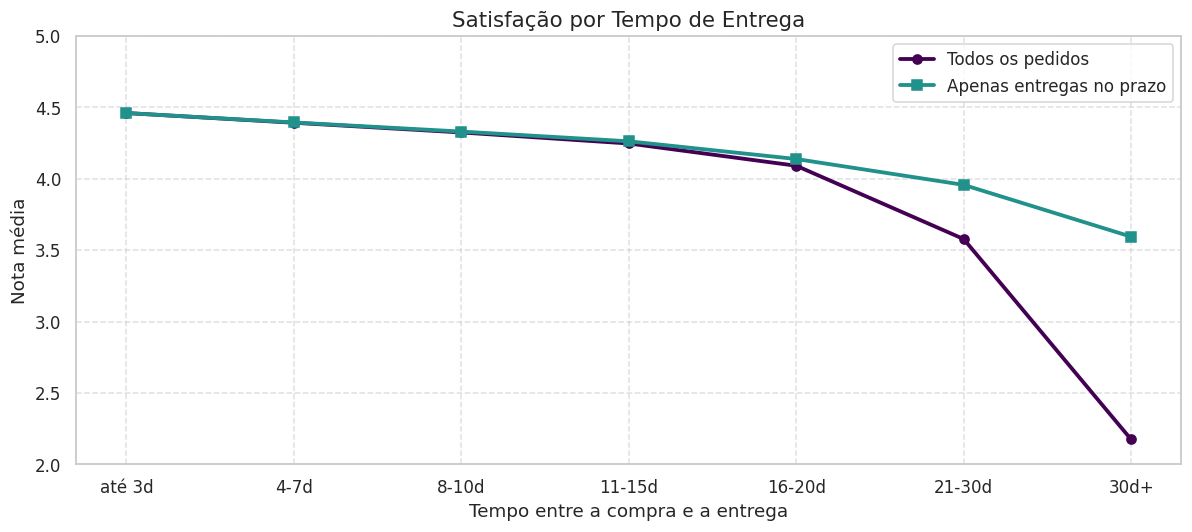

In [28]:
# Comparação: efeito bruto x efeito controlado
plt.figure(figsize=(11, 5))

plt.plot(review_por_tempo['tempo_entrega'].astype(str),
         review_por_tempo['nota_media'],
         marker='o', linewidth=2.5, label='Todos os pedidos', color='#440154')

plt.plot(tempo_controlado['tempo_entrega'].astype(str),
         tempo_controlado['nota_media'],
         marker='s', linewidth=2.5, label='Apenas entregas no prazo', color='#21918c')

plt.xlabel('Tempo entre a compra e a entrega')
plt.ylabel('Nota média')
plt.title('Satisfação por Tempo de Entrega', fontsize=14)
plt.ylim(2, 5)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [29]:
# Correlação entre tempo de entrega e nota
print('Correlação tempo de entrega x nota (todos os pedidos): '
      f"{df[['tempo_entrega', 'review_score']].corr().iloc[0, 1]:.3f}")
print('Correlação tempo de entrega x nota (apenas no prazo):  '
      f"{df_no_prazo[['tempo_entrega', 'review_score']].corr().iloc[0, 1]:.3f}")

Correlação tempo de entrega x nota (todos os pedidos): -0.334
Correlação tempo de entrega x nota (apenas no prazo):  -0.125


A análise do tempo de entrega exigiu um controle metodológico. Na visão bruta, as faixas de prazo mais
longo concentram também os pedidos atrasados, de modo que o efeito observado seria uma mistura de duas
causas distintas. Para isolar o efeito do tempo em si, a análise foi repetida sobre o subconjunto de
pedidos entregues estritamente dentro do prazo prometido.

O resultado é o achado mais relevante desta seção: mesmo entre pedidos que cumpriram integralmente o
prazo, a nota cai de forma consistente conforme o tempo absoluto aumenta, com diferença de cerca de
0,9 ponto entre a faixa mais rápida e a mais lenta.

A implicação prática é que cumprir o prazo prometido não neutraliza o efeito da lentidão. A percepção do
cliente responde ao tempo absoluto de espera, e não apenas ao cumprimento contratual do prazo. Prazos
longos, ainda que honrados, produzem insatisfação por si próprios.

## 4.6 Review por categoria

In [30]:
# Satisfação por categoria de produto (mínimo de 500 pedidos)
review_por_categoria = df.groupby('categoria').agg(
    pedidos=('review_score', 'size'),
    nota_media=('review_score', 'mean'),
    pct_nota_1=('review_score', lambda x: (x == 1).mean() * 100),
    taxa_atraso=('atrasado', 'mean'),
    tempo_entrega=('tempo_entrega', 'mean'),
    preco_mediano=('preco', 'median')
).query('pedidos >= 500')

review_por_categoria['taxa_atraso'] *= 100

# Efeito próprio: nota da categoria apenas nas entregas no prazo,
# comparada à média geral das entregas no prazo
media_no_prazo = df_no_prazo['review_score'].mean()

review_por_categoria['nota_no_prazo'] = (
    df_no_prazo.groupby('categoria')['review_score'].mean()
)
review_por_categoria['efeito_proprio'] = (
    review_por_categoria['nota_no_prazo'] - media_no_prazo
)

review_por_categoria = review_por_categoria.sort_values('nota_media')
review_por_categoria.round(2)

,pedidos,nota_media,pct_nota_1,taxa_atraso,tempo_entrega,preco_mediano,nota_no_prazo,efeito_proprio
categoria,,,,,,,,
office_furniture,1236,3.65,17.15,8.01,20.17,159.99,3.76,-0.53
bed_bath_table,9072,4.01,11.78,7.36,12.51,89.00,4.15,-0.14
outros,1369,4.02,13.59,7.09,12.21,93.02,4.17,-0.12
telephony,4052,4.06,10.34,7.08,12.48,29.99,4.18,-0.11
furniture_decor,6167,4.07,11.30,7.09,12.58,79.90,4.20,-0.09
computers_accessories,6469,4.08,11.24,6.29,12.70,86.50,4.21,-0.08
baby,2741,4.12,10.51,8.03,12.18,85.00,4.30,0.01
watches_gifts,5430,4.13,10.28,7.27,12.30,139.90,4.28,-0.01
electronics,2488,4.13,9.93,7.64,12.45,21.90,4.27,-0.02


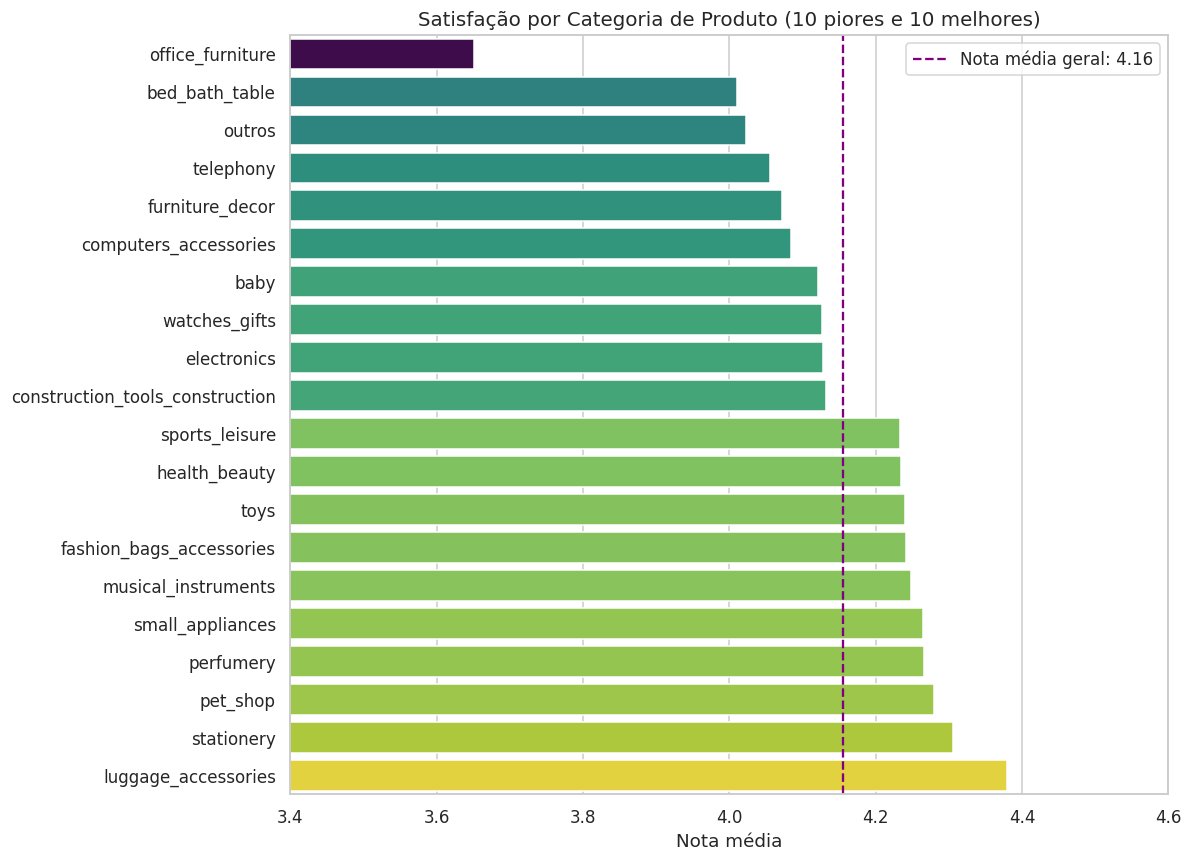

In [31]:
# Gráfico das 10 piores e 10 melhores categorias
piores = review_por_categoria.head(10)
melhores = review_por_categoria.tail(10)
comparativo = pd.concat([piores, melhores]).reset_index()

plt.figure(figsize=(11, 8))

sns.barplot(
    data=comparativo,
    y='categoria',
    x='nota_media',
    hue='nota_media',
    palette='viridis',
    legend=False
)

plt.axvline(df['review_score'].mean(), color='purple', linestyle='--', linewidth=1.5,
            label=f"Nota média geral: {df['review_score'].mean():.2f}")

plt.xlabel('Nota média')
plt.ylabel('')
plt.title('Satisfação por Categoria de Produto (10 piores e 10 melhores)', fontsize=13)
plt.xlim(3.4, 4.6)
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Verificar se o efeito da categoria persiste após controlar o atraso
print('Amplitude da nota bruta entre categorias:      '
      f"{review_por_categoria['nota_media'].max() - review_por_categoria['nota_media'].min():.2f}")
print('Amplitude do efeito próprio (sem atraso):      '
      f"{review_por_categoria['efeito_proprio'].max() - review_por_categoria['efeito_proprio'].min():.2f}")

print('\nCategorias com maior efeito próprio negativo:')
print(review_por_categoria[['pedidos', 'nota_media', 'efeito_proprio',
                            'tempo_entrega']].head(5).round(2))

Amplitude da nota bruta entre categorias:      0.73
Amplitude do efeito próprio (sem atraso):      0.70

Categorias com maior efeito próprio negativo:
                  pedidos  nota_media  efeito_proprio  tempo_entrega
categoria                                                           
office_furniture     1236        3.65           -0.53          20.17
bed_bath_table       9072        4.01           -0.14          12.51
outros               1369        4.02           -0.12          12.21
telephony            4052        4.06           -0.11          12.48
furniture_decor      6167        4.07           -0.09          12.58


A análise por categoria foi restrita a categorias com no mínimo 500 pedidos, evitando que categorias de
baixíssimo volume produzam médias instáveis, mesma precaução adotada na frente regional em relação a
estados pequenos.

Além da nota bruta, foi calculado o **efeito próprio** de cada categoria, definido como a nota média
considerando apenas entregas no prazo, comparada à média geral nessa mesma condição. Essa métrica separa
o que é característica do produto do que é consequência da logística.

O resultado mostra que a categoria, tomada isoladamente, é um driver fraco. A amplitude total é inferior
a um ponto, e a maior parte das categorias se concentra em uma faixa estreita em torno da média.

A exceção relevante é `office_furniture`, que apresenta a pior nota do conjunto e mantém desvio negativo
expressivo mesmo após o controle de atraso, associado a um tempo médio de entrega muito acima do
observado nas demais categorias. Trata-se de um caso específico de produto volumoso com cadeia logística
própria, e não de um padrão generalizável a móveis ou a bens duráveis. Excluída essa categoria, o efeito
de categoria aproxima-se de ruído estatístico.

## 4.7 Review por região e por estado

In [33]:
# Mapear estados para macrorregiões
regioes = {
    'Norte':        ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste':     ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Sudeste':      ['ES', 'MG', 'RJ', 'SP'],
    'Sul':          ['PR', 'RS', 'SC']
}

mapa_regiao = {uf: regiao for regiao, ufs in regioes.items() for uf in ufs}
df['regiao'] = df['customer_state'].map(mapa_regiao)
df_no_prazo['regiao'] = df_no_prazo['customer_state'].map(mapa_regiao)

In [34]:
# Satisfação por região
review_por_regiao = df.groupby('regiao').agg(
    pedidos=('review_score', 'size'),
    nota_media=('review_score', 'mean'),
    pct_nota_1=('review_score', lambda x: (x == 1).mean() * 100),
    taxa_atraso=('atrasado', 'mean'),
    tempo_entrega=('tempo_entrega', 'mean'),
    frete_medio=('frete', 'mean')
)

review_por_regiao['taxa_atraso'] *= 100
review_por_regiao['nota_no_prazo'] = df_no_prazo.groupby('regiao')['review_score'].mean()
review_por_regiao['pct_da_base'] = (
    review_por_regiao['pedidos'] / review_por_regiao['pedidos'].sum() * 100
)

review_por_regiao.sort_values('nota_media').round(2)

,pedidos,nota_media,pct_nota_1,taxa_atraso,tempo_entrega,frete_medio,nota_no_prazo,pct_da_base
regiao,,,,,,,,
Nordeste,8975,3.97,13.04,12.49,19.46,35.98,4.23,9.37
Norte,1779,4.03,11.02,8.32,22.06,41.29,4.20,1.86
Centro-Oeste,5594,4.13,9.96,6.45,14.53,26.41,4.26,5.84
Sudeste,65731,4.18,9.46,6.01,10.25,19.81,4.30,68.60
Sul,13745,4.19,8.83,5.81,13.52,24.35,4.30,14.34


In [35]:
# Quanto do gap regional é explicado por logística?
amplitude_bruta = (
    review_por_regiao['nota_media'].max() - review_por_regiao['nota_media'].min()
)
amplitude_controlada = (
    review_por_regiao['nota_no_prazo'].max() - review_por_regiao['nota_no_prazo'].min()
)

print(f'Amplitude bruta entre regiões:        {amplitude_bruta:.3f}')
print(f'Amplitude controlando o atraso:       {amplitude_controlada:.3f}')
print(f'\nRedução da diferença regional: '
      f'{(1 - amplitude_controlada / amplitude_bruta) * 100:.0f}%')

Amplitude bruta entre regiões:        0.221
Amplitude controlando o atraso:       0.101

Redução da diferença regional: 55%


In [36]:
# Satisfação por estado (mínimo de 500 pedidos)
review_por_estado = df.groupby('customer_state').agg(
    pedidos=('review_score', 'size'),
    nota_media=('review_score', 'mean'),
    pct_nota_1=('review_score', lambda x: (x == 1).mean() * 100),
    taxa_atraso=('atrasado', 'mean'),
    tempo_entrega=('tempo_entrega', 'mean'),
    frete_medio=('frete', 'mean')
).query('pedidos >= 500')

review_por_estado['taxa_atraso'] *= 100
review_por_estado['nota_no_prazo'] = (
    df_no_prazo.groupby('customer_state')['review_score'].mean()
)

review_por_estado.sort_values('nota_media').round(2)

,pedidos,nota_media,pct_nota_1,taxa_atraso,tempo_entrega,frete_medio,nota_no_prazo
customer_state,,,,,,,
MA,712,3.83,15.73,17.13,20.99,42.95,4.17
PA,933,3.91,14.36,10.72,23.18,39.48,4.15
BA,3229,3.93,13.22,11.89,18.78,29.97,4.14
CE,1273,3.94,13.51,13.67,20.76,36.52,4.25
RJ,12211,3.97,14.74,11.92,14.78,23.92,4.24
PB,512,4.08,10.94,10.16,19.77,48.95,4.27
ES,1969,4.08,11.02,10.41,15.15,24.46,4.26
PE,1579,4.08,11.59,9.44,17.89,35.89,4.30
GO,1946,4.10,9.87,6.37,15.10,26.09,4.23


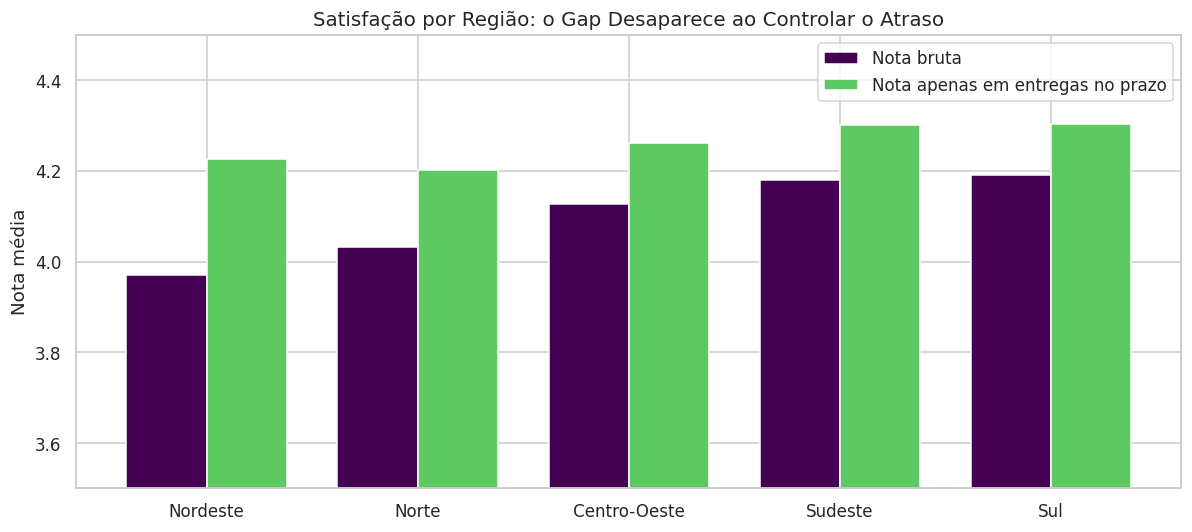

In [37]:
# Gráfico comparativo: nota bruta x nota controlada por região
regiao_plot = review_por_regiao.sort_values('nota_media').reset_index()

x = np.arange(len(regiao_plot))
largura = 0.38

plt.figure(figsize=(11, 5))

plt.bar(x - largura/2, regiao_plot['nota_media'], largura,
        label='Nota bruta', color='#440154')
plt.bar(x + largura/2, regiao_plot['nota_no_prazo'], largura,
        label='Nota apenas em entregas no prazo', color='#5ec962')

plt.xticks(x, regiao_plot['regiao'])
plt.ylabel('Nota média')
plt.title('Satisfação por Região: o Gap Desaparece ao Controlar o Atraso', fontsize=13)
plt.ylim(3.5, 4.5)
plt.legend()

plt.tight_layout()
plt.show()

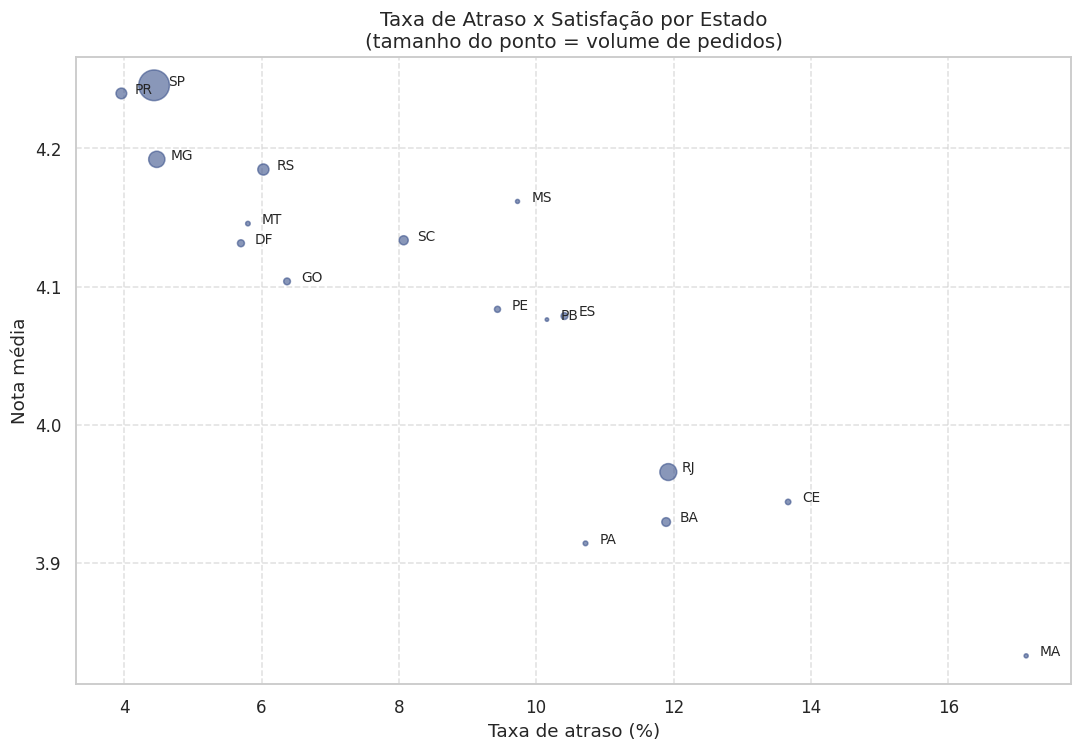

In [38]:
# Relação entre taxa de atraso e nota por estado
plt.figure(figsize=(10, 7))

plt.scatter(
    review_por_estado['taxa_atraso'],
    review_por_estado['nota_media'],
    s=review_por_estado['pedidos'] / 100,
    alpha=0.6,
    color='#3b528b'
)

for uf, linha in review_por_estado.iterrows():
    plt.text(linha['taxa_atraso'] + 0.2, linha['nota_media'], uf, fontsize=9)

plt.xlabel('Taxa de atraso (%)')
plt.ylabel('Nota média')
plt.title('Taxa de Atraso x Satisfação por Estado\n(tamanho do ponto = volume de pedidos)',
          fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

A análise regional confirma e complementa o diagnóstico da frente regional do trabalho. Nordeste e
Norte apresentam as menores notas médias e, simultaneamente, as maiores taxas de atraso, os maiores
tempos de entrega e os maiores fretes médios.

O controle metodológico, no entanto, produz o achado mais importante desta seção: ao considerar somente
as entregas realizadas dentro do prazo, a diferença de satisfação entre regiões cai pela metade e todas
as macrorregiões convergem para uma faixa estreita.

A conclusão é que **não existe diferença relevante de exigência entre consumidores de diferentes
regiões**. O que existe é diferença de nível de serviço. A insatisfação do Norte e do Nordeste é
consequência direta do desequilíbrio estrutural de oferta identificado na análise regional, no qual a
concentração de vendedores no Sudeste impõe distâncias maiores e prazos mais longos aos consumidores
distantes.

A análise por estado revela ainda um caso que a leitura por região oculta. O Rio de Janeiro, segunda
maior praça do país em volume, apresenta a maior proporção de notas 1 de todo o dataset, com taxa de
atraso próxima à observada em estados do Nordeste, apesar de estar no Sudeste e a curta distância do
principal polo vendedor. Ao controlar o atraso, sua nota converge para o padrão do Sudeste, o que
confirma tratar-se de um problema estritamente operacional. Pela combinação de volume elevado e
distância curta, o Rio de Janeiro representa a correção logística de melhor relação entre custo e
retorno em toda a malha.

## 4.8 Riscos de churn

In [39]:
# Taxa de recompra na base de clientes
frequencia = df.groupby('customer_unique_id').size()

print(f'Clientes únicos: {len(frequencia):,}')
print(f'Clientes com apenas 1 pedido: {(frequencia == 1).mean() * 100:.2f}%')
print(f'Clientes com 2 ou mais pedidos: {(frequencia > 1).mean() * 100:.2f}%')

Clientes únicos: 92,747
Clientes com apenas 1 pedido: 97.02%
Clientes com 2 ou mais pedidos: 2.98%


In [40]:
# Definir a janela de retorno de forma empírica
# Entre os clientes que recompraram, em quanto tempo isso ocorreu?
df_recorrentes = df[df['customer_unique_id'].map(frequencia) > 1].sort_values(
    'order_purchase_timestamp'
)
df_recorrentes['ordem_pedido'] = (
    df_recorrentes.groupby('customer_unique_id').cumcount() + 1
)

primeira = df_recorrentes[df_recorrentes['ordem_pedido'] == 1].set_index(
    'customer_unique_id')['order_purchase_timestamp']
segunda = df_recorrentes[df_recorrentes['ordem_pedido'] == 2].set_index(
    'customer_unique_id')['order_purchase_timestamp']

intervalo = (segunda - primeira).dt.days.dropna()

print(f'Mediana de dias até a segunda compra: {intervalo.median():.0f}')
for percentil in [0.50, 0.75, 0.90]:
    print(f'  P{int(percentil * 100)}: {intervalo.quantile(percentil):.0f} dias')

JANELA = int(intervalo.quantile(0.90))
print(f'\nJanela adotada: {JANELA} dias')

Mediana de dias até a segunda compra: 28
  P50: 28 dias
  P75: 126 dias
  P90: 247 dias

Janela adotada: 246 dias


In [41]:
# Construir a base de análise de churn
# Considera-se apenas clientes com maturidade suficiente para terem retornado
data_final = df['order_purchase_timestamp'].max()

primeiro_pedido = df.sort_values('order_purchase_timestamp').groupby(
    'customer_unique_id').first()
primeiro_pedido['voltou'] = frequencia > 1
primeiro_pedido['recencia'] = (
    data_final - df.groupby('customer_unique_id')['order_purchase_timestamp'].max()
).dt.days

base_madura = primeiro_pedido[primeiro_pedido['recencia'] >= JANELA].copy()

print(f'Base madura: {len(base_madura):,} clientes')
print(f'Taxa de não retorno: {(~base_madura["voltou"]).mean() * 100:.1f}%')

Base madura: 40,776 clientes
Taxa de não retorno: 97.3%


A definição de churn exigiu uma adaptação metodológica. Com aproximadamente 97% dos clientes realizando
uma única compra, não existe histórico de repetição suficiente para treinar um modelo clássico de
predição de churn: praticamente todos os registros pertenceriam à classe positiva.

Adotou-se, portanto, a medição do **risco de não retorno após a primeira compra**. A janela de
observação foi definida empiricamente a partir da distribuição do intervalo entre a primeira e a segunda
compra dos clientes que efetivamente recompraram. Adotou-se o percentil 90 desse intervalo como corte,
e a análise foi restrita aos clientes cuja última compra é anterior a esse prazo, garantindo que
tiveram tempo hábil para retornar.

In [42]:
# Matriz de risco: atraso x satisfação declarada
base_madura['grupo_nota'] = np.where(
    base_madura['review_score'] <= 2, 'Detrator (nota 1-2)', 'Demais (nota 3-5)'
)
base_madura['situacao'] = base_madura['atrasado'].map({0: 'No prazo', 1: 'Com atraso'})

matriz_risco = base_madura.pivot_table(
    index='situacao',
    columns='grupo_nota',
    values='voltou',
    aggfunc='mean'
) * 100

matriz_risco.round(2)

grupo_nota,Demais (nota 3-5),Detrator (nota 1-2)
situacao,,
Com atraso,1.74,1.49
No prazo,2.71,3.14


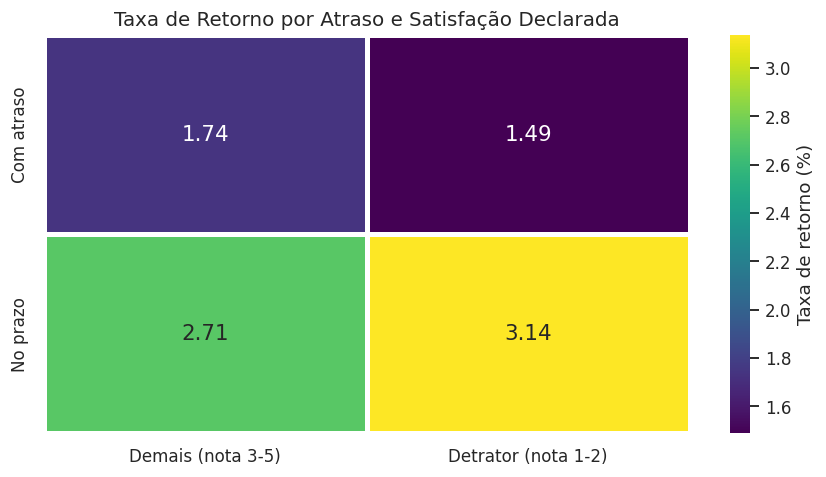

In [43]:
# Visualizar a matriz de risco
plt.figure(figsize=(8, 4.5))

sns.heatmap(
    matriz_risco,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    linewidths=2,
    linecolor='white',
    cbar_kws={'label': 'Taxa de retorno (%)'},
    annot_kws={'fontsize': 14}
)

plt.title('Taxa de Retorno por Atraso e Satisfação Declarada', fontsize=13)
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [44]:
# Segmentação de risco de não retorno
def classificar_risco(linha):
    if linha['atrasado'] == 1 and linha['review_score'] <= 2:
        return 'A. Atraso com queixa'
    elif linha['atrasado'] == 1:
        return 'B. Atraso sem queixa'
    elif linha['review_score'] <= 2:
        return 'C. Queixa sem atraso'
    elif linha['review_score'] == 4:
        return 'D. Silencioso (nota 4)'
    else:
        return 'E. Satisfeito'

base_madura['segmento'] = base_madura.apply(classificar_risco, axis=1)

taxa_geral = base_madura['voltou'].mean()

segmentos = base_madura.groupby('segmento').agg(
    clientes=('voltou', 'size'),
    taxa_retorno=('voltou', 'mean')
)

segmentos['taxa_retorno'] *= 100
segmentos['pct_da_base'] = segmentos['clientes'] / segmentos['clientes'].sum() * 100
segmentos['indice'] = segmentos['taxa_retorno'] / (taxa_geral * 100)

segmentos.round(2)

,clientes,taxa_retorno,pct_da_base,indice
segmento,,,,
A. Atraso com queixa,1411,1.49,3.46,0.55
B. Atraso sem queixa,863,1.74,2.12,0.65
C. Queixa sem atraso,3571,3.14,8.76,1.17
D. Silencioso (nota 4),8081,2.36,19.82,0.88
E. Satisfeito,26850,2.81,65.85,1.05


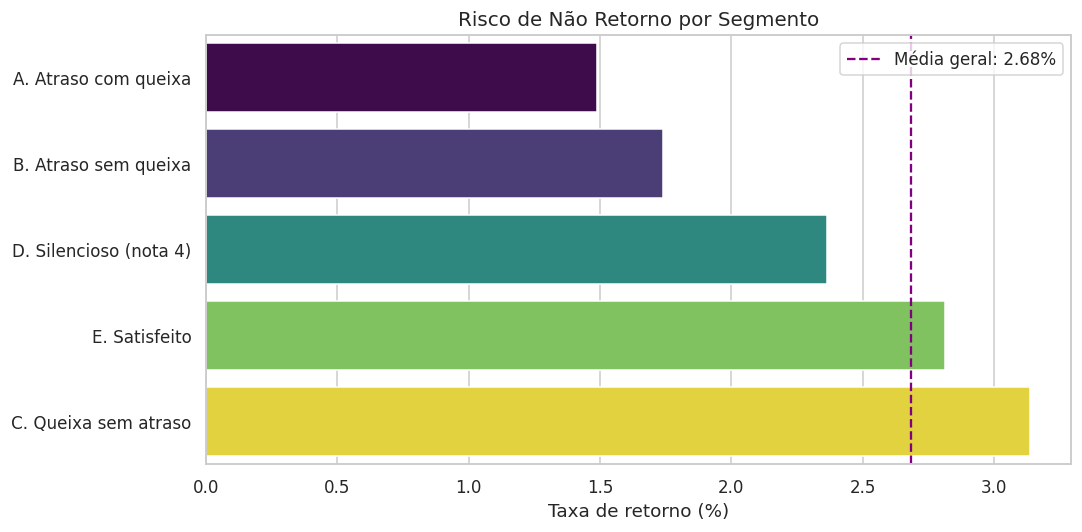

In [45]:
# Gráfico dos segmentos de risco
seg_plot = segmentos.sort_values('taxa_retorno').reset_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=seg_plot,
    y='segmento',
    x='taxa_retorno',
    hue='taxa_retorno',
    palette='viridis',
    legend=False
)

plt.axvline(taxa_geral * 100, color='purple', linestyle='--', linewidth=1.5,
            label=f'Média geral: {taxa_geral * 100:.2f}%')

plt.xlabel('Taxa de retorno (%)')
plt.ylabel('')
plt.title('Risco de Não Retorno por Segmento', fontsize=13)
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# Dimensionamento dos cenários de recuperação
ticket_medio = (df['preco'] + df['frete']).mean()
clientes_totais = len(frequencia)
clientes_com_atraso = df[df['atrasado'] == 1]['customer_unique_id'].nunique()

retorno_atrasados = matriz_risco.loc['Com atraso'].mean() / 100
retorno_no_prazo = matriz_risco.loc['No prazo'].mean() / 100

# Cenário 1: eliminar completamente os atrasos
ganho_cenario_1 = clientes_com_atraso * (retorno_no_prazo - retorno_atrasados)

# Cenário 2: elevar o retorno geral a 10%, patamar de e-commerce com CRM ativo
ganho_cenario_2 = clientes_totais * (0.10 - taxa_geral)

print(f'Ticket médio: R$ {ticket_medio:.2f}\n')
print('Cenário 1 - eliminar todos os atrasos:')
print(f'  Clientes recuperados: {ganho_cenario_1:,.0f}')
print(f'  Receita incremental: R$ {ganho_cenario_1 * ticket_medio:,.0f}\n')
print('Cenário 2 - elevar o retorno de {:.1f}% para 10%:'.format(taxa_geral * 100))
print(f'  Clientes recuperados: {ganho_cenario_2:,.0f}')
print(f'  Receita incremental: R$ {ganho_cenario_2 * ticket_medio:,.0f}\n')
print(f'Razão entre os cenários: {ganho_cenario_2 / ganho_cenario_1:.0f}x')
print(f'\nBase de compra única: {(frequencia == 1).sum():,} clientes')
print(f'Valor dormente (uma recompra por cliente): '
      f'R$ {(frequencia == 1).sum() * ticket_medio:,.0f}')

Ticket médio: R$ 159.56

Cenário 1 - eliminar todos os atrasos:
  Clientes recuperados: 83
  Receita incremental: R$ 13,255

Cenário 2 - elevar o retorno de 2.7% para 10%:
  Clientes recuperados: 6,786
  Receita incremental: R$ 1,082,850

Razão entre os cenários: 82x

Base de compra única: 89,983 clientes
Valor dormente (uma recompra por cliente): R$ 14,357,966


A matriz de risco produz o achado mais contraintuitivo desta análise.

Lendo a matriz pelas linhas, o atraso reduz a taxa de retorno praticamente pela metade. Lendo pelas
colunas, a nota atribuída pelo cliente não apresenta efeito relevante: clientes que registraram nota 1
ou 2 e receberam o pedido no prazo retornam em proporção equivalente, e por vezes superior, à dos
clientes satisfeitos.

A conclusão metodológica é que **`review_score` não é um preditor útil de churn neste conjunto de
dados**. O que prediz o comportamento futuro é o fato operacional ocorrido, não a satisfação declarada.
Um modelo de risco de churn construído sobre a nota do cliente teria baixo poder discriminatório.

A segmentação revela ainda um grupo de risco que a análise por nota média não captura: os clientes de
nota 4. Representam parcela expressiva da base, apresentam taxa de retorno abaixo da média geral e são
o grupo com menor propensão a escrever comentários. Trata-se de insatisfação silenciosa, invisível tanto
nos indicadores agregados quanto no conteúdo qualitativo da plataforma.

O dimensionamento financeiro dos dois cenários encerra a análise. Eliminar integralmente os atrasos
recuperaria um volume modesto de clientes, porque a taxa de retorno base é muito baixa em qualquer
condição. Elevar a taxa de retorno ao patamar típico de operações de e-commerce com CRM ativo geraria
receita incremental de ordem de grandeza dezenas de vezes superior.

O problema de retenção da plataforma, portanto, não é a perda de clientes insatisfeitos. É a ausência
de qualquer mecanismo de reengajamento sobre uma base de compradores que realizou uma única transação
e nunca foi novamente acionada.

# 5. Construção do Painel de Satisfação

Seguindo a mesma lógica metodológica aplicada na frente regional, os indicadores individuais analisados
na Seção 4 foram consolidados por estado em um painel único, utilizando `customer_state` como chave de
relacionamento.

O painel reúne quatro variáveis: nota média, percentual de detratores, taxa de atraso e tempo médio de
entrega. Ele constitui a base para a construção dos indicadores compostos apresentados na Seção 6.

In [47]:
# Consolidar os indicadores de satisfação por estado
painel_satisfacao = review_por_estado[[
    'pedidos', 'nota_media', 'pct_nota_1', 'taxa_atraso',
    'tempo_entrega', 'nota_no_prazo'
]].copy()

# Percentual de detratores (notas 1 a 3)
painel_satisfacao['pct_detratores'] = (
    df[df['customer_state'].isin(painel_satisfacao.index)]
    .groupby('customer_state')['review_score']
    .apply(lambda x: (x <= 3).mean() * 100)
)

painel_satisfacao = painel_satisfacao.reset_index()
painel_satisfacao.round(2)

,customer_state,pedidos,nota_media,pct_nota_1,taxa_atraso,tempo_entrega,nota_no_prazo,pct_detratores
0,BA,3229,3.93,13.22,11.89,18.78,4.14,27.13
1,CE,1273,3.94,13.51,13.67,20.76,4.25,27.18
2,DF,2070,4.13,10.29,5.70,12.50,4.26,21.16
3,ES,1969,4.08,11.02,10.41,15.15,4.26,22.91
4,GO,1946,4.10,9.87,6.37,15.10,4.23,22.71
5,MA,712,3.83,15.73,17.13,20.99,4.17,29.78
6,MG,11285,4.19,8.95,4.47,11.52,4.28,20.12
7,MS,699,4.16,10.16,9.73,15.20,4.36,20.74
8,MT,879,4.15,9.22,5.80,17.50,4.25,21.27
9,PA,933,3.91,14.36,10.72,23.18,4.15,27.76


# 6. Construção dos Indicadores (Satisfação e Operacional)

Objetivo:

Normalização dos dados;

Criação do indicador de satisfação percebida;

Criação do indicador de execução logística;

Criação da Matriz de Risco de Satisfação.

In [48]:
# Normalizar os dados e criar novas colunas com os scores
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

painel_satisfacao[
    ['score_nota',
     'score_detratores',
     'score_atraso',
     'score_tempo']
] = scaler.fit_transform(
    painel_satisfacao[
        ['nota_media',
         'pct_detratores',
         'taxa_atraso',
         'tempo_entrega']
    ]
) * 100

In [49]:
# Inverter os indicadores em que valores menores representam melhor desempenho
painel_satisfacao['score_detratores'] = 100 - painel_satisfacao['score_detratores']
painel_satisfacao['score_atraso'] = 100 - painel_satisfacao['score_atraso']
painel_satisfacao['score_tempo'] = 100 - painel_satisfacao['score_tempo']

In [50]:
# Criar o score de satisfação percebida
painel_satisfacao['score_satisfacao'] = (
    painel_satisfacao['score_nota'] * 0.60 +
    painel_satisfacao['score_detratores'] * 0.40
)

# Criar o score de execução logística
painel_satisfacao['score_execucao'] = (
    painel_satisfacao['score_atraso'] * 0.60 +
    painel_satisfacao['score_tempo'] * 0.40
)

In [51]:
# Calcular as medianas para classificação
mediana_satisfacao = painel_satisfacao['score_satisfacao'].median()
mediana_execucao = painel_satisfacao['score_execucao'].median()

print(f'Mediana de satisfação: {mediana_satisfacao:.1f}')
print(f'Mediana de execução:   {mediana_execucao:.1f}')

Mediana de satisfação: 64.3
Mediana de execução:   55.2


In [52]:
# Criar função para classificar os Estados de acordo com as medianas
def classificar_risco_estado(linha):

    if (
        linha['score_satisfacao'] >= mediana_satisfacao
        and linha['score_execucao'] >= mediana_execucao
    ):
        return 'Saudável'

    elif (
        linha['score_satisfacao'] < mediana_satisfacao
        and linha['score_execucao'] >= mediana_execucao
    ):
        return 'Investigar causa não logística'

    elif (
        linha['score_satisfacao'] >= mediana_satisfacao
        and linha['score_execucao'] < mediana_execucao
    ):
        return 'Risco latente'

    else:
        return 'Corrigir com urgência'


painel_satisfacao['classificacao'] = (
    painel_satisfacao.apply(classificar_risco_estado, axis=1)
)

In [53]:
# Visualizar a tabela classificada
painel_satisfacao[
    [
        'customer_state',
        'pedidos',
        'nota_media',
        'taxa_atraso',
        'score_satisfacao',
        'score_execucao',
        'classificacao'
    ]
].sort_values('score_satisfacao').round(2)

,customer_state,pedidos,nota_media,taxa_atraso,score_satisfacao,score_execucao,classificacao
5,MA,712,3.83,17.13,-0.00,5.90,Corrigir com urgência
9,PA,933,3.91,10.72,18.95,29.22,Corrigir com urgência
0,BA,3229,3.93,11.89,23.42,35.70,Corrigir com urgência
1,CE,1273,3.94,13.67,25.35,22.30,Corrigir com urgência
13,RJ,12211,3.97,11.92,30.72,46.29,Corrigir com urgência
10,PB,512,4.08,10.16,55.68,40.93,Corrigir com urgência
3,ES,1969,4.08,10.41,60.00,52.18,Corrigir com urgência
11,PE,1579,4.08,9.44,61.53,49.27,Corrigir com urgência
4,GO,1946,4.10,6.37,64.32,70.71,Saudável
15,SC,3519,4.13,8.07,71.58,64.86,Saudável


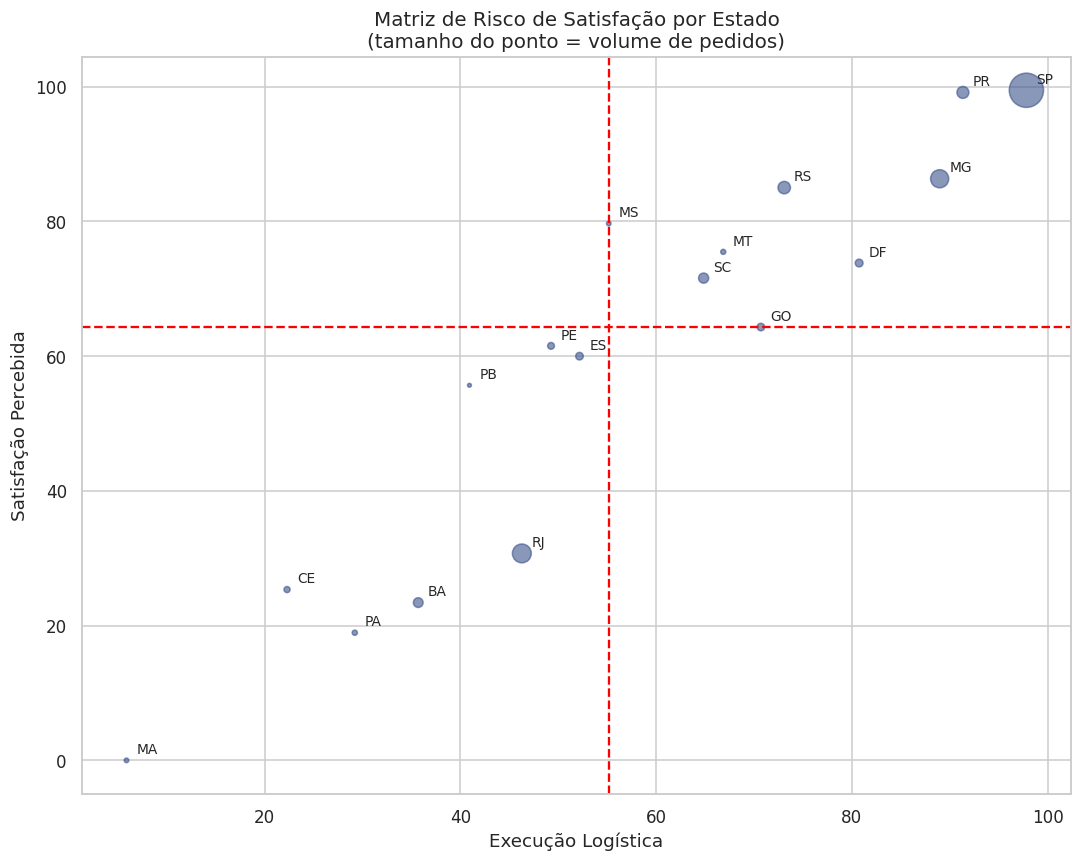

In [54]:
# Matriz de Risco de Satisfação
plt.figure(figsize=(10, 8))

plt.scatter(
    painel_satisfacao['score_execucao'],
    painel_satisfacao['score_satisfacao'],
    s=painel_satisfacao['pedidos'] / 80,
    alpha=0.6,
    color='#3b528b'
)

for i, linha in painel_satisfacao.iterrows():
    plt.text(
        linha['score_execucao'] + 1,
        linha['score_satisfacao'] + 1,
        linha['customer_state'],
        fontsize=9
    )

plt.axvline(mediana_execucao, linestyle='--', color='red')
plt.axhline(mediana_satisfacao, linestyle='--', color='red')

plt.xlabel('Execução Logística')
plt.ylabel('Satisfação Percebida')
plt.title('Matriz de Risco de Satisfação por Estado\n(tamanho do ponto = volume de pedidos)',
          fontsize=13)

plt.tight_layout()
plt.show()

Como os indicadores do painel apresentam escalas distintas, foi realizada a normalização das variáveis
com `MinMaxScaler`, transformando todos os valores para uma escala de 0 a 100. O procedimento replica a
abordagem adotada na frente regional, garantindo consistência metodológica entre as duas análises.

Para os indicadores em que valores menores representam melhor desempenho, especificamente percentual de
detratores, taxa de atraso e tempo de entrega, a escala foi posteriormente invertida, de modo que
valores maiores passem a representar melhor condição.

O **Score de Satisfação Percebida** combina nota média com peso de 60% e percentual de detratores com
peso de 40%. A nota média representa a avaliação central do cliente, enquanto o percentual de detratores
captura a cauda negativa, que é a parcela com maior potencial de dano reputacional.

O **Score de Execução Logística** combina taxa de atraso com peso de 60% e tempo médio de entrega com
peso de 40%, refletindo o achado da Seção 4.5 de que o descumprimento do prazo é mais determinante que a
lentidão absoluta, sem que esta seja irrelevante.

A classificação dos estados utiliza as medianas de cada score como linhas de corte, produzindo quatro
quadrantes. O quadrante de maior interesse gerencial é o de baixa satisfação com boa execução logística,
pois indica insatisfação cuja causa não é explicada pela operação de entrega e que, portanto, demanda
investigação em produto, atendimento ou mix de vendedores.

# 7. Conclusão

**Visão geral**

A satisfação do cliente na plataforma é fundamentalmente uma função da execução logística. A nota média
próxima de 4,2 e o NPS adaptado positivo escondem uma distribuição polarizada, na qual cerca de um em
cada dez pedidos recebe a nota mínima.

**Sobre a distribuição e os temas**

A distribuição em J indica que a média isolada é um indicador pobre para acompanhamento gerencial. O
text mining revelou que o tema mais destrutivo não é o atraso, e sim a ausência de resposta ao cliente,
seguida de pedidos de reembolso e de relatos de não recebimento. A falha operacional é tolerada; o
silêncio posterior a ela não é. Registra-se ainda que clientes insatisfeitos comentam com frequência
muito superior à dos satisfeitos, o que amplifica a exposição reputacional de cada ocorrência.

**Sobre os drivers**

Entre as variáveis testadas, o atraso é isoladamente dominante, com amplitude de cerca de dois pontos na
escala. O tempo absoluto de entrega possui efeito próprio relevante mesmo entre pedidos entregues no
prazo, o que indica que cumprir o prazo prometido não neutraliza o desconforto da espera longa.

O preço não se confirmou como driver. A amplitude entre as faixas de valor é próxima de zero e o sinal
observado é levemente invertido, com produtos de maior valor recebendo notas ligeiramente superiores.
Não há, portanto, evidência de penalização reputacional associada a preço elevado.

A categoria apresenta efeito fraco quando controlado o atraso, com exceção de `office_furniture`, caso
específico de produto volumoso com cadeia logística própria.

**Sobre a região**

Nordeste e Norte apresentam as menores notas, mas ao considerar apenas entregas realizadas no prazo a
diferença entre regiões cai pela metade. Não há evidência de diferença de exigência entre consumidores
de regiões distintas: há diferença de nível de serviço, decorrente do desequilíbrio estrutural de oferta
identificado na frente regional deste trabalho.

A análise por estado identificou o Rio de Janeiro como caso de atenção prioritária: segunda maior praça
em volume, apresenta a maior proporção de notas mínimas do dataset e taxa de atraso comparável à de
estados do Nordeste, apesar da proximidade geográfica ao principal polo vendedor. Por combinar volume
elevado e distância curta, representa a intervenção logística com melhor relação entre custo e retorno.

**Sobre o churn**

Com aproximadamente 97% de compradores de aquisição única, a base não sustenta um modelo clássico de
predição de churn. A análise de risco de não retorno mostrou que o atraso reduz a probabilidade de
recompra praticamente pela metade, enquanto a nota atribuída não apresenta poder preditivo. A satisfação
declarada, portanto, não é um indicador confiável de retenção neste contexto.

O dimensionamento dos cenários indica que a oportunidade financeira não está na prevenção de churn por
qualidade de serviço, mas na criação de um mecanismo de reengajamento inexistente. A base de compradores
de transação única representa um valor dormente de ordem de grandeza muito superior ao recuperável pela
correção logística isolada.

**Recomendações**

1. Estabelecer SLA de resposta ao cliente em ocorrências de atraso, atuando dentro da janela de 72 horas
identificada como ponto de ruptura da percepção.
2. Priorizar a correção operacional do Rio de Janeiro, pela combinação de alto volume e baixa distância.
3. Reduzir o tempo absoluto de entrega, e não apenas garantir o cumprimento do prazo prometido.
4. Substituir o acompanhamento por nota média pelo monitoramento do percentual de detratores e do
segmento de nota 4, que concentra insatisfação silenciosa.
5. Implantar programa de reengajamento da base de compradores de transação única, identificado como a
maior oportunidade financeira desta frente de análise.

# 8. Limitações e Trabalhos Futuros

1. A avaliação é disparada no momento da entrega, o que faz de `review_score` uma medida de experiência
de recebimento e não de qualidade de produto. Atributos de uso e durabilidade não são capturados.

2. A base contém pedidos com mais de uma avaliação, parte deles com notas divergentes. Adotou-se a
avaliação mais recente, mas o critério alternativo (média das avaliações) produziria resultados
levemente distintos.

3. A classificação temática por expressões regulares não captura ironia, negação nem erros de grafia.
Uma abordagem por modelo de linguagem tende a elevar a precisão da taxonomia.

4. Não foi possível avaliar o efeito do atendimento pós-venda de forma direta, pois o dataset não
contém registros de chamados ou interações de suporte, apesar de o tema aparecer como o mais crítico na
análise textual.

5. Recomenda-se investigar o efeito da fragmentação de pedidos multi-vendedor sobre a satisfação,
variável presente nos dados e não explorada em profundidade nesta frente.

6. Recomenda-se incorporar a análise de distância geográfica real entre vendedor e cliente, a partir da
tabela `geolocation`, para separar o efeito de distância do efeito de estado.